In [63]:
# diffusion maps -> data compression and possibly clustering (p4), but it is rather to embed the data and use some other tool
# spectral clustering - finds a new representation of the data points and uses K-Means on them

In [14]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

np.random.seed(42)

In [60]:
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.cluster import KMeans
from sklearn.datasets import make_circles

## Spectral clustering

In [61]:
def compute_L(W, normalized):
    d = np.sum(W, axis=1)
    
    if normalized:
        d[d == 0] = 1e-10
        D_inv_sqrt = np.diag(1 / np.sqrt(d))
        L = np.eye(W.shape[0]) - D_inv_sqrt @ W @ D_inv_sqrt
    else:
        D = np.diag(d)
        L = D - W
        
    return L

def spectral_clustering(W, k, normalized=False, random_seed=None):
    L = compute_L(W, normalized)
    # ascending order
    _, eigenvectors = np.linalg.eigh(L)
    Y = eigenvectors[:, :k]

    # k-means clustering
    kmeans = KMeans(n_clusters=k, random_state=random_seed, n_init="auto")
    kmeans.fit(Y)
    cluster_labels = kmeans.labels_

    return cluster_labels

def cheegers_cut(W, indices):
    n = W.shape[0]
    all_indices = np.arange(n)
    complementary_indices = np.setdiff1d(all_indices, indices)
    
    cut = np.sum(W[np.ix_(indices, complementary_indices)])
    vol1 = np.sum(W[indices, :])
    vol2 = np.sum(W[complementary_indices, :])
    min_vol = min(vol1, vol2)
    
    return cut / min_vol

def binary_spectral_clustering(W):
    L = compute_L(W, normalized=True)
    _, eigenvectors = np.linalg.eigh(L)
    w = eigenvectors[:, 1]
    
    d = np.sum(W, axis=1)
    D_inv_half = np.diag(np.sqrt(1 / d))
    
    y = D_inv_half @ w
    order = np.argsort(y)
    
    n = W.shape[0]
    best_score = np.inf
    best_split_index = 0
    for i in range(1, n-1):
        indices = order[:i]
        score = cheegers_cut(W, indices)
        if score < best_score:
            best_score = score
            best_split_index = i
    
    clustering_labels = np.ones(n)
    clustering_labels[order[:best_split_index]] = 0
    
    return clustering_labels

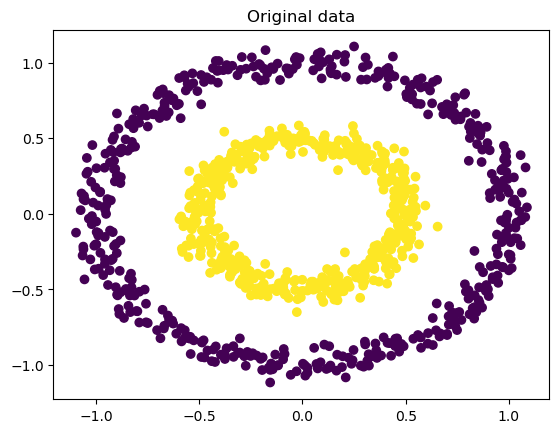

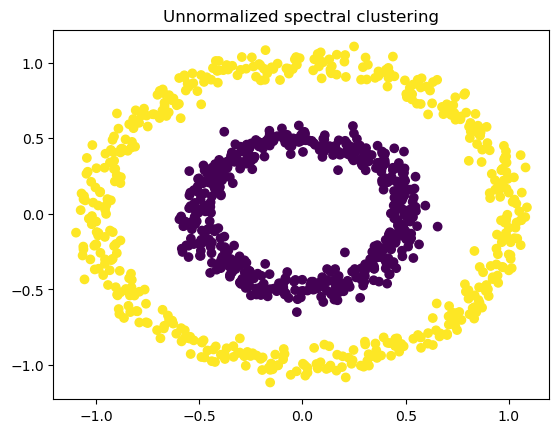

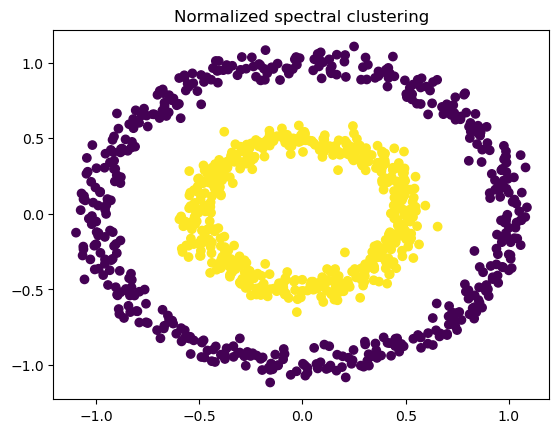

In [62]:
# example usage - circles
X, y = make_circles(n_samples=1000, factor=0.5, noise=0.05)

W_complete = rbf_kernel(X, gamma=20)
W = W_complete * (W_complete > 0.1)  

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title('Original data')
plt.show()

labels1 = spectral_clustering(W, 2, normalized=False)

plt.scatter(X[:, 0], X[:, 1], c=labels1)
plt.title('Unnormalized spectral clustering')
plt.show()

labels2 = spectral_clustering(W, 2, normalized=True)

plt.scatter(X[:, 0], X[:, 1], c=labels2)
plt.title('Normalized spectral clustering')
plt.show()

## Experiments

In [37]:
# loading adjacency matrix
A = pd.read_csv("competition/D3-UNC.csv", header=None).values

In [38]:
np.all(A == A.T)

True

In [40]:
# creating an undirected graph - A is always symmetric
G = nx.from_numpy_array(A)

# optionally
# G = nx.from_numpy_array(A, create_using=nx.DiGraph)

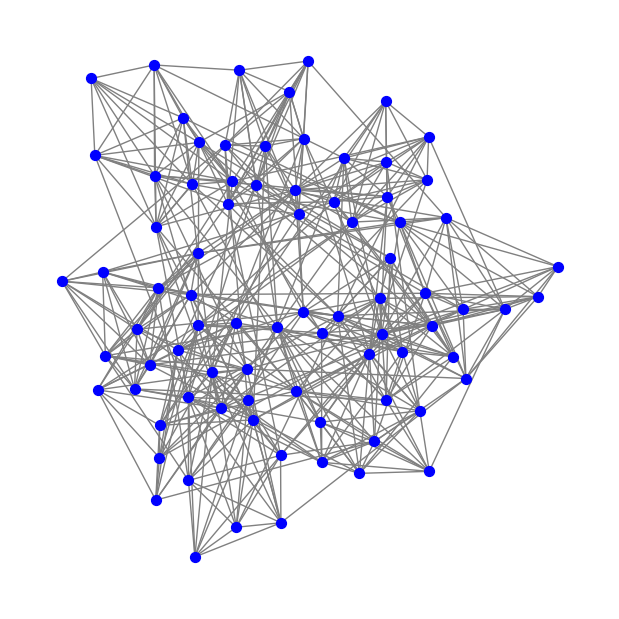

In [45]:
plt.figure(figsize=(6, 6))
pos = nx.spring_layout(G)
nx.draw(
    G, pos,
    with_labels=False,
    node_size=50,
    node_color="blue",
    edge_color="gray"
)
plt.show()

In [55]:
# transition matrix

# normalization - dividing by column sums
P = A / A.sum(axis=0)
P

array([[0.        , 0.125     , 0.11111111, ..., 0.        , 0.        ,
        0.        ],
       [0.06666667, 0.        , 0.11111111, ..., 0.        , 0.        ,
        0.        ],
       [0.06666667, 0.125     , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.09090909,
        0.08333333],
       [0.        , 0.        , 0.        , ..., 0.07142857, 0.        ,
        0.08333333],
       [0.        , 0.        , 0.        , ..., 0.07142857, 0.09090909,
        0.        ]])

In [52]:
# optionally
# row_sums = A.sum(axis=1, keepdims=True)
# P = np.divide(A, row_sums, where=row_sums != 0)
# P

array([[0.        , 0.06666667, 0.06666667, ..., 0.        , 0.        ,
        0.        ],
       [0.125     , 0.        , 0.125     , ..., 0.        , 0.        ,
        0.        ],
       [0.11111111, 0.11111111, 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.07142857,
        0.07142857],
       [0.        , 0.        , 0.        , ..., 0.09090909, 0.        ,
        0.09090909],
       [0.        , 0.        , 0.        , ..., 0.08333333, 0.08333333,
        0.        ]])

True